# HotpotQA Span FFT vs Full Cross-Encoder

这个 notebook 直接复用 HotpotQA 的 span 扫描缓存，只针对单个 `span` 做比较：

- 不运行 LiteSemRAG 的扫描、索引建立、HDBSCAN。
- 从 scan cache 取出这个 span 的全部文本出现位置。
- 重新建立这些文本的 embedding。
- 用 `farthest_first_traversal` 选样本，只对样本跑 cross-encoder，然后按 LiteSemRAG 当前算法把剩余样本分类。
- 再对全部样本逐个跑 cross-encoder。
- 直接展示文本结果和可视化，不保存结果到本地。

如果要换词，只需要修改 `TARGET_SPAN` 这一组参数，然后从下往下重新运行。

In [1]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "jupyter_notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")

Working directory: /home/xiaoyue/LiteSemRAG


In [2]:
from collections import Counter, defaultdict
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from IPython.display import display
from sentence_transformers import CrossEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoModel, AutoTokenizer

from text_processing import get_token_indices_for_phrase, normalize_text
from utils import (
    build_wikidata_candidate_bank as shared_build_wikidata_candidate_bank,
    extract_cross_encoder_scores,
    farthest_first_traversal,
    load_wikidata_definition_candidates as shared_load_wikidata_definition_candidates,
)
from wikidata_utils import fetch_detailed_descriptions_for_entities
from llm_semantic_labeler import (
    DEFAULT_CACHE_PATH as DEFAULT_LLM_CACHE_PATH,
    DEFAULT_CONTEXT_WORD_WINDOW as DEFAULT_LLM_CONTEXT_WORD_WINDOW,
    DEFAULT_MAX_TOKENS as DEFAULT_LLM_MAX_TOKENS,
    choose_wikidata_candidate_with_llm,
)
from local_llm import LocalLLMClient, LocalLLMConfig


In [3]:
HOTPOT_SCAN_STORE_PATH = Path("hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_all.pkl")
DEFAULT_CROSS_ENCODER_MODEL = "cross-encoder/nli-deberta-v3-large"
DEFAULT_TEXT_ENCODER_NAME_OR_PATH = "/home/xiaoyue/ProtoGraphRAG/deberta-v3-large"
DEFAULT_BATCH_SIZE = 16
DEFAULT_MAX_LENGTH = 512
DEFAULT_CONTEXT_MODE = "sentence_neighbors"  # "sentence", "sentence_neighbors", "full_text"
DEFAULT_REDUCTION_METHOD = "pca"  # "pca" or "tsne"
DEFAULT_RANDOM_STATE = 42
DEFAULT_CONSENSUS_RATIO_THRESHOLD = 0.8
DEFAULT_D1_D2_RATIO_THRESHOLD = 0.8
DEFAULT_MAX_SAMPLES = 10
DEFAULT_QUERY_KIND = None

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
pd.set_option("display.max_colwidth", None)
print(f"Device: {DEVICE}")


Device: cuda


In [4]:
def load_hotpot_scan_store(scan_store_path: Path = HOTPOT_SCAN_STORE_PATH):
    if not scan_store_path.exists():
        raise FileNotFoundError(
            f"HotpotQA scan store not found at {scan_store_path}. Please prepare the scan cache first."
        )

    with scan_store_path.open("rb") as handle:
        store = pickle.load(handle)

    print(f"Loaded scan-only store from {scan_store_path}")
    print(store["stats"])
    return store


embedding_store = load_hotpot_scan_store()

Loaded scan-only store from hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_all.pkl
{'num_documents': 66581, 'num_unique_terms': 634624, 'num_phrase_occurrences': 1007780, 'num_token_occurrences': 584999, 'num_total_occurrences': 1592779}


In [5]:
def lookup_records(store, query_text, kind=None, include_text=True, include_cleaned_text=True):
    normalized_query = normalize_text(query_text.strip())
    records = list(store["index"].get(normalized_query, []))

    if kind is not None:
        records = [record for record in records if record["kind"] == kind]

    if not include_text and not include_cleaned_text:
        return records

    enriched_records = []
    for record in records:
        item = dict(record)
        document_idx = item["document_idx"]
        if include_text:
            item["text"] = store["documents"][document_idx]["text"]
        if include_cleaned_text:
            item["cleaned_text"] = store["cleaned_documents"][document_idx]
        enriched_records.append(item)
    return enriched_records


def _find_left_boundary(text: str, index: int) -> int:
    return max(
        text.rfind(".", 0, index),
        text.rfind("!", 0, index),
        text.rfind("?", 0, index),
    )


def _find_right_boundary(text: str, index: int) -> int:
    right_candidates = [
        text.find(".", index),
        text.find("!", index),
        text.find("?", index),
    ]
    right_candidates = [idx for idx in right_candidates if idx != -1]
    return len(text) if not right_candidates else min(right_candidates) + 1


def _build_context_from_bounds(cleaned_text, span, context_start, context_end):
    start_char, end_char = span
    context_raw = cleaned_text[context_start:context_end]

    if not context_raw.strip():
        context_start = max(0, start_char - 120)
        context_end = min(len(cleaned_text), end_char + 120)
        context_raw = cleaned_text[context_start:context_end]

    left_trim = len(context_raw) - len(context_raw.lstrip())
    context_text = context_raw.strip()

    local_start = start_char - context_start - left_trim
    local_end = end_char - context_start - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
    }


def extract_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = _find_left_boundary(cleaned_text, start_char)
    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = _find_right_boundary(cleaned_text, end_char)
    return _build_context_from_bounds(cleaned_text, span, context_start, context_end)


def extract_neighbor_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = _find_left_boundary(cleaned_text, start_char)
    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = _find_right_boundary(cleaned_text, end_char)

    if context_start > 0:
        previous_boundary = _find_left_boundary(cleaned_text, max(0, context_start - 1))
        context_start = 0 if previous_boundary == -1 else previous_boundary + 1

    if context_end < len(cleaned_text):
        context_end = _find_right_boundary(cleaned_text, context_end)

    return _build_context_from_bounds(cleaned_text, span, context_start, context_end)


def extract_full_context(cleaned_text, span):
    start_char, end_char = span
    context_raw = cleaned_text
    left_trim = len(context_raw) - len(context_raw.lstrip())
    context_text = context_raw.strip()

    local_start = start_char - left_trim
    local_end = end_char - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
    }


def extract_prompt_context(cleaned_text, span, prompt_context_mode="sentence"):
    if prompt_context_mode == "sentence":
        return extract_sentence_context(cleaned_text, span)
    if prompt_context_mode == "full_text":
        return extract_full_context(cleaned_text, span)
    if prompt_context_mode == "sentence_neighbors":
        return extract_neighbor_sentence_context(cleaned_text, span)
    raise ValueError(
        f"Unsupported prompt_context_mode={prompt_context_mode!r}. Use 'sentence', 'sentence_neighbors', or 'full_text'."
    )


def build_hotpot_prompt(
    record,
    query_text,
    mark_target=False,
    left_marker="[TGT]",
    right_marker="[/TGT]",
    prompt_context_mode="sentence",
):
    context_info = extract_prompt_context(
        record["cleaned_text"],
        record["span"],
        prompt_context_mode=prompt_context_mode,
    )
    context_text = context_info["context_text"]
    local_start, local_end = context_info["local_span"]
    prompt_context = context_text

    if mark_target:
        prompt_context = (
            f"{context_text[:local_start]}{left_marker} {context_text[local_start:local_end]} {right_marker}{context_text[local_end:]}"
        )

    prompt_text = (
        f"Context: {prompt_context}\n"
        f"Target word: {query_text.strip()}\n\n"
        f'Question: What does "{query_text.strip()}" mean in this context?'
    )

    return {
        "context_text": context_text,
        "matched_text": context_text[local_start:local_end],
        "local_span": (local_start, local_end),
        "prompt_text": prompt_text,
    }


In [6]:
def load_wikidata_definition_candidates(
    query_text: str,
    use_detailed_description: bool = True,
    exact_match_text: bool = False,
    filter_name: bool = True,
    require_detailed_description: bool = False,
    candidate_limit: int = 5,
):
    return shared_load_wikidata_definition_candidates(
        query_text,
        use_detailed_description=use_detailed_description,
        exact_match_text=exact_match_text,
        limit=int(candidate_limit),
        filter_name=filter_name,
        require_detailed_description=require_detailed_description,
    )


def build_wikidata_candidate_bank(candidates_df: pd.DataFrame, definition_column: str):
    return shared_build_wikidata_candidate_bank(candidates_df, definition_column)


In [7]:
text_tokenizer = None
text_encoder_model = None
cross_encoder_model = None


def load_text_encoder(name_or_path: str, device: str):
    loaded_tokenizer = AutoTokenizer.from_pretrained(
        name_or_path,
        local_files_only=True,
        fix_mistral_regex=True,
        use_fast=True,
    )
    if not getattr(loaded_tokenizer, "is_fast", False):
        raise RuntimeError(
            "The text encoder tokenizer must be a fast tokenizer because offset_mapping is required."
        )

    loaded_model = AutoModel.from_pretrained(
        name_or_path,
        local_files_only=True,
    )
    loaded_model.to(device)
    loaded_model.eval()
    return loaded_tokenizer, loaded_model


def ensure_text_encoder_loaded(name_or_path: str, device: str):
    global text_tokenizer, text_encoder_model
    if text_tokenizer is None or text_encoder_model is None:
        text_tokenizer, text_encoder_model = load_text_encoder(name_or_path, device)
        print(f"Loaded text encoder on {device}: {name_or_path}")
    return text_tokenizer, text_encoder_model


def ensure_cross_encoder_loaded(model_name: str):
    global cross_encoder_model
    if cross_encoder_model is None:
        cross_encoder_model = CrossEncoder(model_name)
        print(f"Loaded cross-encoder: {model_name}")
    return cross_encoder_model


def encode_span_text_batch(text_list, tokenizer, model, device, max_length=512):
    encoded_inputs = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    offsets = encoded_inputs["offset_mapping"]
    model_inputs = {key: value.to(device) for key, value in encoded_inputs.items() if key != "offset_mapping"}

    with torch.no_grad():
        outputs = model(**model_inputs, output_hidden_states=True)
        token_embeddings = outputs.hidden_states[-2].detach().cpu()

    return token_embeddings, offsets


In [8]:
def collect_query_span_embeddings(
    store,
    query_text,
    kind=None,
    batch_size=DEFAULT_BATCH_SIZE,
    max_length=DEFAULT_MAX_LENGTH,
    prompt_context_mode=DEFAULT_CONTEXT_MODE,
    mark_target=False,
    max_records=None,
    text_encoder_name_or_path=None,
    device=DEVICE,
):
    normalized_query = normalize_text(query_text.strip())
    query_records = lookup_records(
        store,
        query_text,
        kind=kind,
        include_text=True,
        include_cleaned_text=True,
    )

    if not query_records:
        raise ValueError(f"No records found for span={query_text!r}.")

    if max_records is not None:
        query_records = query_records[: int(max_records)]

    embedding_cache = store.setdefault("embedding_cache", {})
    encoder_name = text_encoder_name_or_path or DEFAULT_TEXT_ENCODER_NAME_OR_PATH
    tokenizer, model = ensure_text_encoder_loaded(encoder_name, device)

    total_records = len(query_records)
    progress_handle = display(
        f"Embedded 0/{total_records} texts for query {normalized_query!r}",
        display_id=True,
    )

    embedded_records = []
    cache_hits = 0
    cache_misses = 0

    for batch_start in range(0, total_records, batch_size):
        batch_end = min(batch_start + batch_size, total_records)
        batch_records = query_records[batch_start:batch_end]

        context_texts = []
        local_spans = []
        matched_texts = []
        batch_embeddings = [None] * len(batch_records)
        uncached_texts = []
        uncached_indices = []
        cache_keys = []

        for local_idx, record in enumerate(batch_records):
            prompt_info = build_hotpot_prompt(
                record,
                query_text,
                mark_target=mark_target,
                prompt_context_mode=prompt_context_mode,
            )
            cache_key = (
                int(record["document_idx"]),
                tuple(record["span"]),
                prompt_context_mode,
                prompt_info["context_text"],
                tuple(prompt_info["local_span"]),
                int(max_length),
                encoder_name,
                "litsemrag_hidden_states_minus_2_mean_pool_context_only",
            )

            matched_texts.append(prompt_info["matched_text"])
            context_texts.append(prompt_info["context_text"])
            local_spans.append(prompt_info["local_span"])
            cache_keys.append(cache_key)

            cached_embedding = embedding_cache.get(cache_key)
            if cached_embedding is None:
                uncached_texts.append(prompt_info["context_text"])
                uncached_indices.append(local_idx)
                cache_misses += 1
            else:
                batch_embeddings[local_idx] = cached_embedding
                cache_hits += 1

        if uncached_texts:
            token_embeddings_batch, offsets_batch = encode_span_text_batch(
                uncached_texts,
                tokenizer,
                model,
                device,
                max_length=max_length,
            )
            for local_idx, token_embeddings, offsets in zip(
                uncached_indices,
                token_embeddings_batch,
                offsets_batch,
            ):
                start_char, end_char = local_spans[local_idx]
                token_indices = get_token_indices_for_phrase(start_char, end_char, offsets.tolist())
                if not token_indices:
                    raise ValueError(
                        f"No tokenizer offsets were found for local_span={(start_char, end_char)} in title={batch_records[local_idx]['title']!r}."
                    )
                embedding = token_embeddings[token_indices].mean(dim=0).to(torch.float32).numpy()
                cache_key = cache_keys[local_idx]
                embedding_cache[cache_key] = embedding
                batch_embeddings[local_idx] = embedding

        for record, matched_text, context_text, local_span, embedding in zip(
            batch_records,
            matched_texts,
            context_texts,
            local_spans,
            batch_embeddings,
        ):
            prompt_info = build_hotpot_prompt(
                record,
                query_text,
                mark_target=mark_target,
                prompt_context_mode=prompt_context_mode,
            )
            item = dict(record)
            item["matched_text"] = matched_text
            item["context_text"] = context_text
            item["local_span"] = local_span
            item["prompt_text"] = prompt_info["prompt_text"]
            item["embedding"] = np.asarray(embedding, dtype=np.float32)
            item["record_index"] = len(embedded_records)
            embedded_records.append(item)

        progress_handle.update(
            f"Embedded {batch_end}/{total_records} texts for query {normalized_query!r}"
        )

    return {
        "query_text": query_text,
        "normalized_query": normalized_query,
        "kind": kind,
        "record_count": len(embedded_records),
        "batch_size": batch_size,
        "max_length": max_length,
        "prompt_context_mode": prompt_context_mode,
        "mark_target": mark_target,
        "max_records": max_records,
        "device": device,
        "text_encoder_name_or_path": encoder_name,
        "embedding_method": "LiteSemRAG span mean-pool from hidden_states[-2]",
        "cache_hits": cache_hits,
        "cache_misses": cache_misses,
        "cache_size": len(embedding_cache),
        "records": embedded_records,
    }


In [9]:
def score_record_candidates(record, candidate_bank, model, batch_size=DEFAULT_BATCH_SIZE):
    pairs = [(record["prompt_text"], candidate["hypothesis"]) for candidate in candidate_bank]
    raw_scores = model.predict(
        pairs,
        batch_size=min(batch_size, len(pairs)),
        show_progress_bar=False,
    )
    scores = extract_cross_encoder_scores(raw_scores, model)
    ranked_candidates = sorted(
        [
            {
                **candidate,
                "score": float(score),
            }
            for candidate, score in zip(candidate_bank, scores)
        ],
        key=lambda item: item["score"],
        reverse=True,
    )
    return ranked_candidates


def classify_records_full_cross_encoder(records, candidate_bank, model, batch_size=DEFAULT_BATCH_SIZE):
    predictions = []
    for record in records:
        ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
        top_candidate = ranked_candidates[0]
        predictions.append(
            {
                "record_index": record["record_index"],
                "assigned_description": top_candidate["description"],
                "predicted_entity_id": top_candidate["entity_id"],
                "predicted_label": top_candidate["label"],
                "predicted_definition": top_candidate["definition"],
                "score": float(top_candidate["score"]),
                "provenance": "full_cross_encoder",
            }
        )
    return predictions


def _cosine_distance_matrix(embeddings: np.ndarray) -> np.ndarray:
    normalized = embeddings / np.clip(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = normalized @ normalized.T
    dists = 1.0 - sims
    return np.clip(dists, 0.0, None)


def _compute_medoid_index_numpy(embeddings: np.ndarray) -> int:
    if len(embeddings) == 1:
        return 0
    dists = _cosine_distance_matrix(embeddings)
    return int(np.argmin(dists.sum(axis=1)))


def _nearest_medoid_distances(record_embedding: np.ndarray, medoid_embeddings: np.ndarray):
    record_vec = record_embedding / max(np.linalg.norm(record_embedding), 1e-12)
    medoid_vecs = medoid_embeddings / np.clip(np.linalg.norm(medoid_embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = medoid_vecs @ record_vec
    dists = np.clip(1.0 - sims, 0.0, None)
    order = np.argsort(dists)
    return dists, order


def classify_records_fft_then_assign(
    records,
    candidate_bank,
    model,
    max_samples=DEFAULT_MAX_SAMPLES,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    batch_size=DEFAULT_BATCH_SIZE,
):
    if not records:
        raise ValueError("records must be non-empty")

    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    if len(records) > max_samples:
        sampled_indices = list(farthest_first_traversal(embeddings, max_samples))
    else:
        sampled_indices = list(range(len(records)))

    sample_prediction_records = []
    description_vote_map = {}
    for sample_order, idx in enumerate(sampled_indices, start=1):
        record = records[idx]
        ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
        top_candidate = ranked_candidates[0]
        description = top_candidate["description"]
        state = description_vote_map.setdefault(
            description,
            {
                "candidate": top_candidate,
                "description": description,
                "count": 0,
                "score_sum": 0.0,
                "score_count": 0,
            },
        )
        state["count"] += 1
        state["score_sum"] += top_candidate["score"]
        state["score_count"] += 1
        sample_prediction_records.append(
            {
                "record_index": record["record_index"],
                "sample_order": sample_order,
                "predicted_description": description,
                "predicted_entity_id": top_candidate["entity_id"],
                "predicted_label": top_candidate["label"],
                "predicted_definition": top_candidate["definition"],
                "prediction_score": float(top_candidate["score"]),
            }
        )

    aggregated_candidates = sorted(
        (
            {
                **state["candidate"],
                "description": state["description"],
                "count": int(state["count"]),
                "score_sum": float(state["score_sum"]),
                "score_count": int(state["score_count"]),
                "score_mean": float(state["score_sum"] / state["score_count"]),
            }
            for state in description_vote_map.values()
            if state["score_count"] > 0
        ),
        key=lambda item: (item["count"], item["score_mean"], item["score_sum"]),
        reverse=True,
    )

    if not aggregated_candidates:
        raise ValueError("No sample predictions were produced.")

    top_aggregated_candidate = aggregated_candidates[0]
    top_description_ratio = top_aggregated_candidate["count"] / len(sample_prediction_records)

    if top_description_ratio >= consensus_ratio_threshold:
        final_assignments = []
        for record in records:
            final_assignments.append(
                {
                    "record_index": record["record_index"],
                    "assigned_description": top_aggregated_candidate["description"],
                    "predicted_entity_id": top_aggregated_candidate["entity_id"],
                    "predicted_label": top_aggregated_candidate["label"],
                    "predicted_definition": top_aggregated_candidate["definition"],
                    "score": float(top_aggregated_candidate["score"]),
                    "provenance": "consensus",
                }
            )
        return {
            "path_taken": "consensus",
            "sampled_indices": sampled_indices,
            "sample_prediction_records": sample_prediction_records,
            "description_counts": {
                item["description"]: item["count"]
                for item in aggregated_candidates
            },
            "top_description": top_aggregated_candidate["description"],
            "top_description_ratio": float(top_description_ratio),
            "top_description_count": int(top_aggregated_candidate["count"]),
            "final_assignments": final_assignments,
            "valid_classes": [top_aggregated_candidate["description"]],
        }

    description_groups = defaultdict(list)
    for record in sample_prediction_records:
        description_groups[record["predicted_description"]].append(record)

    valid_classes = {
        description: group
        for description, group in description_groups.items()
        if len(group) >= 2
    }
    if len(valid_classes) < 2:
        raise ValueError(
            "Consensus failed but fewer than 2 valid classes with >=2 samples were found. "
            f"class sizes={{{', '.join(f'{desc!r}: {len(group)}' for desc, group in description_groups.items())}}}"
        )

    records_by_index = {record["record_index"]: record for record in records}
    sampled_index_set = {records[idx]["record_index"] for idx in sampled_indices}
    final_assignments = []
    class_medoid_embeddings = {}

    for description, group in valid_classes.items():
        class_records = [records_by_index[item["record_index"]] for item in group]
        class_embeddings = np.stack([record["embedding"] for record in class_records]).astype(np.float32)
        medoid_idx = _compute_medoid_index_numpy(class_embeddings)
        class_medoid_embeddings[description] = class_embeddings[medoid_idx]
        for item in group:
            final_assignments.append(
                {
                    "record_index": item["record_index"],
                    "assigned_description": description,
                    "predicted_entity_id": item["predicted_entity_id"],
                    "predicted_label": item["predicted_label"],
                    "predicted_definition": item["predicted_definition"],
                    "score": float(item["prediction_score"]),
                    "provenance": "class_seed",
                }
            )

    medoid_descriptions = list(class_medoid_embeddings.keys())
    medoid_embeddings = np.stack([class_medoid_embeddings[desc] for desc in medoid_descriptions]).astype(np.float32)

    for record in records:
        record_index = record["record_index"]
        if any(item["record_index"] == record_index for item in final_assignments):
            continue

        dists, order = _nearest_medoid_distances(record["embedding"], medoid_embeddings)
        d1 = float(dists[order[0]])
        d2 = float(dists[order[1]]) if len(order) > 1 else float("inf")
        ratio = (d1 / d2) if np.isfinite(d2) and d2 > 0 else float("inf")

        if np.isfinite(d2) and d2 > 0 and ratio <= d1_d2_ratio_threshold:
            chosen_desc = medoid_descriptions[int(order[0])]
            final_assignments.append(
                {
                    "record_index": record_index,
                    "assigned_description": chosen_desc,
                    "predicted_entity_id": None,
                    "predicted_label": None,
                    "predicted_definition": None,
                    "score": None,
                    "provenance": "d1_d2",
                    "d1": d1,
                    "d2": d2,
                    "ratio": ratio,
                    "was_sampled": record_index in sampled_index_set,
                }
            )
            continue

        ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
        top_candidate = ranked_candidates[0]
        final_assignments.append(
            {
                "record_index": record_index,
                "assigned_description": top_candidate["description"],
                "predicted_entity_id": top_candidate["entity_id"],
                "predicted_label": top_candidate["label"],
                "predicted_definition": top_candidate["definition"],
                "score": float(top_candidate["score"]),
                "provenance": "model_judgment",
                "d1": d1,
                "d2": d2,
                "ratio": ratio,
                "was_sampled": record_index in sampled_index_set,
            }
        )

    final_assignments.sort(key=lambda item: item["record_index"])
    return {
        "path_taken": "split",
        "sampled_indices": sampled_indices,
        "sample_prediction_records": sample_prediction_records,
        "description_counts": {
            item["description"]: item["count"]
            for item in aggregated_candidates
        },
        "top_description": top_aggregated_candidate["description"],
        "top_description_ratio": float(top_description_ratio),
        "top_description_count": int(top_aggregated_candidate["count"]),
        "final_assignments": final_assignments,
        "valid_classes": medoid_descriptions,
    }

In [10]:
def build_assignment_frame(records, assignments, method_name):
    assignment_lookup = {item["record_index"]: item for item in assignments}
    rows = []
    for record in records:
        item = assignment_lookup[record["record_index"]]
        rows.append(
            {
                "record_index": record["record_index"],
                "title": record["title"],
                "kind": record["kind"],
                "matched_text": record["matched_text"],
                "source_text": record["context_text"],
                "assigned_description": item["assigned_description"],
                "predicted_label": item.get("predicted_label"),
                "predicted_entity_id": item.get("predicted_entity_id"),
                "predicted_definition": item.get("predicted_definition"),
                "score": item.get("score"),
                "provenance": item.get("provenance"),
                "llm_reason": item.get("llm_reason"),
                "llm_cache_hit": item.get("llm_cache_hit"),
                "method": method_name,
            }
        )
    return pd.DataFrame(rows).sort_values(["record_index"]).reset_index(drop=True)


def classify_records_with_llm(
    records,
    candidate_bank,
    *,
    cache_path=DEFAULT_LLM_CACHE_PATH,
    context_word_window=DEFAULT_LLM_CONTEXT_WORD_WINDOW,
    config=None,
    client=None,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    llm_client = client or LocalLLMClient(config)
    assignments = []
    cache_hit_count = 0
    progress_handle = display(
        f"LLM-labeled 0/{len(records)} records",
        display_id=True,
    )

    for idx, record in enumerate(records, start=1):
        result = choose_wikidata_candidate_with_llm(
            span_text=record.get("matched_text") or record.get("query_span") or "",
            context_text=record["context_text"],
            matched_text=record.get("matched_text"),
            local_span=record.get("local_span"),
            candidate_bank=candidate_bank,
            cache_path=cache_path,
            context_word_window=context_word_window,
            config=config,
            client=llm_client,
            max_tokens=max_tokens,
        )
        if result["cache_hit"]:
            cache_hit_count += 1
        selected_candidate = result["selected_candidate"]
        assignments.append(
            {
                "record_index": record["record_index"],
                "assigned_description": selected_candidate.get("description"),
                "predicted_label": selected_candidate.get("label"),
                "predicted_entity_id": selected_candidate.get("entity_id"),
                "predicted_definition": selected_candidate.get("definition"),
                "score": None,
                "provenance": "llm_semantic_label",
                "llm_reason": result.get("reason"),
                "llm_cache_hit": bool(result.get("cache_hit")),
            }
        )
        if idx % 20 == 0 or idx == len(records):
            progress_handle.update(f"LLM-labeled {idx}/{len(records)} records")

    return {
        "assignments": assignments,
        "cache_hits": cache_hit_count,
        "cache_misses": len(records) - cache_hit_count,
        "provider": llm_client.config.provider,
        "model": llm_client.config.model,
        "total_tokens": llm_client.total_tokens,
    }


def compare_assignment_frames(
    fft_df: pd.DataFrame,
    full_df: pd.DataFrame,
    llm_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    merged = fft_df.merge(
        full_df[["record_index", "assigned_description", "score"]].rename(
            columns={
                "assigned_description": "full_cross_encoder_description",
                "score": "full_cross_encoder_score",
            }
        ),
        on="record_index",
        how="inner",
    )
    merged = merged.rename(
        columns={
            "assigned_description": "fft_assignment_description",
            "score": "fft_assignment_score",
        }
    )
    merged["same_assignment"] = (
        merged["fft_assignment_description"] == merged["full_cross_encoder_description"]
    )

    if llm_df is not None:
        merged = merged.merge(
            llm_df[
                [
                    "record_index",
                    "assigned_description",
                    "predicted_label",
                    "predicted_entity_id",
                    "predicted_definition",
                    "provenance",
                    "llm_reason",
                    "llm_cache_hit",
                ]
            ].rename(
                columns={
                    "assigned_description": "llm_assignment_description",
                    "predicted_label": "llm_predicted_label",
                    "predicted_entity_id": "llm_predicted_entity_id",
                    "predicted_definition": "llm_predicted_definition",
                    "provenance": "llm_provenance",
                }
            ),
            on="record_index",
            how="left",
        )
        merged["fft_matches_llm"] = (
            merged["fft_assignment_description"] == merged["llm_assignment_description"]
        )
        merged["full_matches_llm"] = (
            merged["full_cross_encoder_description"] == merged["llm_assignment_description"]
        )

    return merged


def summarize_assignments(
    comparison_df: pd.DataFrame,
    fft_result: dict,
    candidates_df: pd.DataFrame,
    llm_result: dict | None = None,
) -> pd.DataFrame:
    fft_counts = Counter(comparison_df["fft_assignment_description"])
    full_counts = Counter(comparison_df["full_cross_encoder_description"])
    llm_counts = Counter(comparison_df["llm_assignment_description"]) if "llm_assignment_description" in comparison_df.columns else Counter()
    all_labels = sorted(set(fft_counts) | set(full_counts) | set(llm_counts))
    rows = []
    for label in all_labels:
        row = {
            "description": label,
            "fft_count": int(fft_counts.get(label, 0)),
            "full_cross_encoder_count": int(full_counts.get(label, 0)),
            "delta_full_minus_fft": int(full_counts.get(label, 0) - fft_counts.get(label, 0)),
        }
        if llm_counts:
            row["llm_count"] = int(llm_counts.get(label, 0))
            row["delta_llm_minus_fft"] = int(llm_counts.get(label, 0) - fft_counts.get(label, 0))
            row["delta_llm_minus_full"] = int(llm_counts.get(label, 0) - full_counts.get(label, 0))
        rows.append(row)
    summary_df = pd.DataFrame(rows)

    print(f"Total records: {len(comparison_df)}")
    print(f"FFT path: {fft_result['path_taken']}")
    print(f"Sampled points: {len(fft_result['sampled_indices'])}")
    print(f"FFT vs full agreement: {int(comparison_df['same_assignment'].sum())} / {len(comparison_df)}")
    print(f"FFT vs full disagreement: {int((~comparison_df['same_assignment']).sum())} / {len(comparison_df)}")
    if "fft_matches_llm" in comparison_df.columns:
        print(f"FFT vs LLM agreement: {int(comparison_df['fft_matches_llm'].sum())} / {len(comparison_df)}")
        print(f"Full vs LLM agreement: {int(comparison_df['full_matches_llm'].sum())} / {len(comparison_df)}")
    print(f"Top sample-vote description: {fft_result['top_description']!r}")
    print(f"Top sample-vote ratio: {fft_result['top_description_ratio']:.3f}")
    print(f"Valid classes used for propagation: {fft_result['valid_classes']}")
    if llm_result is not None:
        print(f"LLM provider/model: {llm_result['provider']} / {llm_result['model']}")
        print(f"LLM cache hits: {llm_result['cache_hits']} | misses: {llm_result['cache_misses']}")
        print(f"LLM total tokens (this run): {llm_result['total_tokens']}")
    display(candidates_df)
    return summary_df


def reduce_embeddings(records, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE):
    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    method = method.lower().strip()
    if method == "pca":
        return PCA(n_components=2, random_state=random_state).fit_transform(embeddings)
    if method == "tsne":
        perplexity = min(30, max(2, len(records) // 3))
        return TSNE(
            n_components=2,
            perplexity=perplexity,
            init="random",
            learning_rate="auto",
            random_state=random_state,
        ).fit_transform(embeddings)
    raise ValueError("method must be one of: pca, tsne")


def plot_assignment_comparison(records, comparison_df, sampled_indices, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE):
    coords = reduce_embeddings(records, method=method, random_state=random_state)
    sampled_mask = np.zeros(len(records), dtype=bool)
    sampled_mask[np.asarray(sampled_indices, dtype=int)] = True

    label_columns = [
        ("fft_assignment_description", f"{method.upper()}: FFT sample -> algorithm propagation"),
        ("full_cross_encoder_description", f"{method.upper()}: full cross-encoder"),
    ]
    if "llm_assignment_description" in comparison_df.columns:
        label_columns.append(
            ("llm_assignment_description", f"{method.upper()}: LLM semantic labeling")
        )

    all_labels = sorted(
        set().union(*[set(comparison_df[column].dropna().tolist()) for column, _ in label_columns])
    )
    base_colors = [
        "#d62728",
        "#1f77b4",
        "#2ca02c",
        "#ff7f0e",
        "#9467bd",
        "#8c564b",
        "#e377c2",
        "#7f7f7f",
        "#bcbd22",
        "#17becf",
    ]
    color_map = {label: base_colors[i % len(base_colors)] for i, label in enumerate(all_labels)}

    for column, title in label_columns:
        fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=140)
        for label in all_labels:
            mask = comparison_df[column].to_numpy() == label
            nonsampled = mask & ~sampled_mask
            sampled = mask & sampled_mask
            ax.scatter(
                coords[nonsampled, 0],
                coords[nonsampled, 1],
                s=28,
                alpha=0.72,
                color=color_map[label],
                label=label,
            )
            if sampled.any():
                ax.scatter(
                    coords[sampled, 0],
                    coords[sampled, 1],
                    s=220,
                    marker="*",
                    edgecolor="black",
                    linewidth=0.9,
                    color=color_map[label],
                )
        ax.set_title(title)
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.grid(alpha=0.2)
        handles, labels = ax.get_legend_handles_labels()
        dedup = dict(zip(labels, handles))
        ax.legend(dedup.values(), dedup.keys(), loc="best", fontsize=8, frameon=True)
        plt.tight_layout()
        plt.show()


def plot_disagreement_only(records, comparison_df, sampled_indices, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE):
    coords = reduce_embeddings(records, method=method, random_state=random_state)
    disagreement_mask = (~comparison_df["same_assignment"]).to_numpy()
    if "fft_matches_llm" in comparison_df.columns:
        disagreement_mask = disagreement_mask | (~comparison_df["fft_matches_llm"]).to_numpy() | (~comparison_df["full_matches_llm"]).to_numpy()
    sampled_mask = np.zeros(len(records), dtype=bool)
    sampled_mask[np.asarray(sampled_indices, dtype=int)] = True

    plt.figure(figsize=(9, 7), dpi=120)
    plt.scatter(coords[:, 0], coords[:, 1], s=20, alpha=0.15, color="lightgray", label="all records")
    if disagreement_mask.any():
        plt.scatter(
            coords[disagreement_mask, 0],
            coords[disagreement_mask, 1],
            s=80,
            alpha=0.85,
            color="crimson",
            label="disagreement",
        )
    sampled_disagreement = disagreement_mask & sampled_mask
    if sampled_disagreement.any():
        plt.scatter(
            coords[sampled_disagreement, 0],
            coords[sampled_disagreement, 1],
            s=220,
            marker="*",
            edgecolor="black",
            linewidth=0.8,
            color="gold",
            label="sampled disagreement",
        )
    plt.title(f"{method.upper()}: disagreement locations")
    plt.xlabel("component 1")
    plt.ylabel("component 2")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()


In [11]:
TARGET_SPAN = "director"
QUERY_KIND = DEFAULT_QUERY_KIND
INPUT_SAMPLE_LIMIT = 100  # e.g. 100
WIKIDATA_CANDIDATE_LIMIT = 2
USE_DETAILED_DESCRIPTION = False
REQUIRE_DETAILED_DESCRIPTION = True
EXACT_MATCH_TEXT = True
FILTER_NAME = True
MARK_TARGET = False
PROMPT_CONTEXT_MODE = DEFAULT_CONTEXT_MODE
EMBED_BATCH_SIZE = DEFAULT_BATCH_SIZE
CROSS_ENCODER_BATCH_SIZE = 32
MAX_LENGTH = DEFAULT_MAX_LENGTH
MAX_SAMPLES = DEFAULT_MAX_SAMPLES
CONSENSUS_RATIO_THRESHOLD = DEFAULT_CONSENSUS_RATIO_THRESHOLD
D1_D2_RATIO_THRESHOLD = DEFAULT_D1_D2_RATIO_THRESHOLD
REDUCTION_METHOD = DEFAULT_REDUCTION_METHOD
RANDOM_STATE = DEFAULT_RANDOM_STATE
TEXT_ENCODER_NAME_OR_PATH = DEFAULT_TEXT_ENCODER_NAME_OR_PATH
CROSS_ENCODER_MODEL_NAME = DEFAULT_CROSS_ENCODER_MODEL
ENABLE_LLM_VALIDATION = True
LLM_PROVIDER = None
LLM_MODEL = None
LLM_API_KEY_FILE = None
LLM_CACHE_PATH = DEFAULT_LLM_CACHE_PATH
LLM_CONTEXT_WORD_WINDOW = DEFAULT_LLM_CONTEXT_WORD_WINDOW
LLM_MAX_TOKENS = DEFAULT_LLM_MAX_TOKENS


In [12]:
candidate_definitions_df, definition_column = load_wikidata_definition_candidates(
    TARGET_SPAN,
    use_detailed_description=USE_DETAILED_DESCRIPTION,
    exact_match_text=EXACT_MATCH_TEXT,
    filter_name=FILTER_NAME,
    require_detailed_description=REQUIRE_DETAILED_DESCRIPTION,
    candidate_limit=WIKIDATA_CANDIDATE_LIMIT,
)
candidate_bank = build_wikidata_candidate_bank(candidate_definitions_df, definition_column)
embedded_result = collect_query_span_embeddings(
    embedding_store,
    TARGET_SPAN,
    kind=QUERY_KIND,
    batch_size=EMBED_BATCH_SIZE,
    max_length=MAX_LENGTH,
    prompt_context_mode=PROMPT_CONTEXT_MODE,
    mark_target=MARK_TARGET,
    max_records=INPUT_SAMPLE_LIMIT,
    text_encoder_name_or_path=TEXT_ENCODER_NAME_OR_PATH,
    device=DEVICE,
)

print(f"Text encoder: {embedded_result['text_encoder_name_or_path']}")
print(f"Embedding method: {embedded_result['embedding_method']}")
print(f"Input sample limit: {embedded_result['max_records']}")
print(f"Candidate count: {len(candidate_bank)}")
print(f"Record count: {embedded_result['record_count']}")
display(candidate_definitions_df)


/home/xiaoyue/anaconda3/envs/llm_graph/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Loaded text encoder on cuda: /home/xiaoyue/ProtoGraphRAG/deberta-v3-large


"Embedded 100/100 texts for query 'director'"

Text encoder: /home/xiaoyue/ProtoGraphRAG/deberta-v3-large
Embedding method: LiteSemRAG span mean-pool from hidden_states[-2]
Input sample limit: 100
Candidate count: 2
Record count: 100


,id,label,description,match_text,aliases,concepturi
0,Q3455803,director,director of a creative work,director,,http://www.wikidata.org/entity/Q3455803
1,Q2526255,film director,person who controls the artistic and dramatic aspects of a film production,director,director,http://www.wikidata.org/entity/Q2526255


In [13]:
cross_encoder = ensure_cross_encoder_loaded(CROSS_ENCODER_MODEL_NAME)
records = embedded_result["records"]
llm_result = None
llm_assignment_df = None

fft_result = classify_records_fft_then_assign(
    records,
    candidate_bank,
    cross_encoder,
    max_samples=MAX_SAMPLES,
    consensus_ratio_threshold=CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=D1_D2_RATIO_THRESHOLD,
    batch_size=CROSS_ENCODER_BATCH_SIZE,
)
full_cross_encoder_assignments = classify_records_full_cross_encoder(
    records,
    candidate_bank,
    cross_encoder,
    batch_size=CROSS_ENCODER_BATCH_SIZE,
)

if ENABLE_LLM_VALIDATION:
    llm_config = LocalLLMConfig.from_env(
        provider=LLM_PROVIDER,
        model=LLM_MODEL,
        api_key_file=LLM_API_KEY_FILE,
    )
    llm_client = LocalLLMClient(llm_config)
    llm_result = classify_records_with_llm(
        records,
        candidate_bank,
        cache_path=LLM_CACHE_PATH,
        context_word_window=LLM_CONTEXT_WORD_WINDOW,
        config=llm_config,
        client=llm_client,
        max_tokens=LLM_MAX_TOKENS,
    )

fft_assignment_df = build_assignment_frame(records, fft_result["final_assignments"], "fft_then_assign")
full_assignment_df = build_assignment_frame(records, full_cross_encoder_assignments, "full_cross_encoder")
if llm_result is not None:
    llm_assignment_df = build_assignment_frame(records, llm_result["assignments"], "llm_semantic_label")
comparison_df = compare_assignment_frames(fft_assignment_df, full_assignment_df, llm_assignment_df)
summary_df = summarize_assignments(comparison_df, fft_result, candidate_definitions_df, llm_result=llm_result)

display(summary_df)


Loaded cross-encoder: cross-encoder/nli-deberta-v3-large


'LLM-labeled 100/100 records'

Total records: 100
FFT path: split
Sampled points: 10
FFT vs full agreement: 77 / 100
FFT vs full disagreement: 23 / 100
FFT vs LLM agreement: 28 / 100
Full vs LLM agreement: 23 / 100
Top sample-vote description: 'director of a creative work'
Top sample-vote ratio: 0.500
Valid classes used for propagation: ['person who controls the artistic and dramatic aspects of a film production', 'director of a creative work']
LLM provider/model: local / meta-llama/Meta-Llama-3-8B-Instruct
LLM cache hits: 100 | misses: 0
LLM total tokens (this run): 0


,id,label,description,match_text,aliases,concepturi
0,Q3455803,director,director of a creative work,director,,http://www.wikidata.org/entity/Q3455803
1,Q2526255,film director,person who controls the artistic and dramatic aspects of a film production,director,director,http://www.wikidata.org/entity/Q2526255


,description,fft_count,full_cross_encoder_count,delta_full_minus_fft,llm_count,delta_llm_minus_fft,delta_llm_minus_full
0,director of a creative work,38,61,23,44,6,-17
1,person who controls the artistic and dramatic aspects of a film production,62,39,-23,56,-6,17


In [14]:
sample_records_df = pd.DataFrame(fft_result["sample_prediction_records"])
if not sample_records_df.empty:
    display(sample_records_df)
else:
    print("No sample prediction records.")

comparison_columns = [
    "record_index",
    "title",
    "kind",
    "matched_text",
    "source_text",
    "fft_assignment_description",
    "full_cross_encoder_description",
    "llm_assignment_description",
    "provenance",
    "same_assignment",
    "fft_matches_llm",
    "full_matches_llm",
    "fft_assignment_score",
    "full_cross_encoder_score",
    "llm_reason",
    "llm_cache_hit",
]
available_comparison_columns = [col for col in comparison_columns if col in comparison_df.columns]
missing_comparison_columns = [col for col in comparison_columns if col not in comparison_df.columns]
if missing_comparison_columns:
    print(f"Skipping missing comparison columns: {missing_comparison_columns}")
display(comparison_df[available_comparison_columns].head(30))


,record_index,sample_order,predicted_description,predicted_entity_id,predicted_label,predicted_definition,prediction_score
0,47,1,person who controls the artistic and dramatic aspects of a film production,Q2526255,film director,person who controls the artistic and dramatic aspects of a film production,-2.955054
1,18,2,person who controls the artistic and dramatic aspects of a film production,Q2526255,film director,person who controls the artistic and dramatic aspects of a film production,-3.503026
2,5,3,person who controls the artistic and dramatic aspects of a film production,Q2526255,film director,person who controls the artistic and dramatic aspects of a film production,-2.550935
3,75,4,director of a creative work,Q3455803,director,director of a creative work,-2.660575
4,68,5,director of a creative work,Q3455803,director,director of a creative work,-1.463003
5,63,6,person who controls the artistic and dramatic aspects of a film production,Q2526255,film director,person who controls the artistic and dramatic aspects of a film production,-2.545503
6,28,7,director of a creative work,Q3455803,director,director of a creative work,-2.046425
7,33,8,director of a creative work,Q3455803,director,director of a creative work,-0.938110
8,23,9,person who controls the artistic and dramatic aspects of a film production,Q2526255,film director,person who controls the artistic and dramatic aspects of a film production,-4.848465
9,14,10,director of a creative work,Q3455803,director,director of a creative work,-2.150935


Skipping missing comparison columns: ['llm_reason', 'llm_cache_hit']


,record_index,title,kind,matched_text,source_text,fft_assignment_description,full_cross_encoder_description,llm_assignment_description,provenance,same_assignment,fft_matches_llm,full_matches_llm,fft_assignment_score,full_cross_encoder_score
0,0,Ed Wood,token,director,"Edward Davis Wood Jr. (october 10, 1924 – december 10, 1978) was an american filmmaker, actor, writer, producer, and director.",director of a creative work,director of a creative work,person who controls the artistic and dramatic aspects of a film production,d1_d2,True,False,False,NaN,-1.388068
1,1,David Weissman,token,director,"David Weissman is a screenwriter and director. his film credits include The Family Man (2000), evolution (2001), and when in rome (2010).",director of a creative work,director of a creative work,person who controls the artistic and dramatic aspects of a film production,model_judgment,True,False,False,-1.386739,-1.386739
2,2,Ambroise Thomas,token,director,"Charles Louis Ambroise Thomas (5 august 1811 – 12 february 1896) was a french composer, best known for his operas mignon (1866) and hamlet (1868, after shakespeare) and as director of the conservatoire de paris from 1871 till his death.",person who controls the artistic and dramatic aspects of a film production,director of a creative work,director of a creative work,d1_d2,False,False,True,NaN,-1.408562
3,3,Ferdinando Provesi,token,director,"bartolomeo cathedral in busseto (the town very close to Le Roncole, the village where verdi was born.) provesi was also director of the municipal music school and local Philharmonic Society. he began teaching verdi in 1824 when the future composer was 11 years old.",person who controls the artistic and dramatic aspects of a film production,director of a creative work,director of a creative work,d1_d2,False,False,True,NaN,-2.111440
4,4,United States Assistant Secretary of State,token,director,"Assistant Secretaries usually manage individual bureaus of the department of state. when the manager of a bureau or another agency holds a title other than Assistant Secretary, such as director, it can be said to be of Assistant Secretary equivalent rank. Assistant Secretaries typically have a set of deputies, referred to as deputy Assistant Secretaries (DAS).",person who controls the artistic and dramatic aspects of a film production,person who controls the artistic and dramatic aspects of a film production,director of a creative work,d1_d2,True,False,False,NaN,-3.374389
5,5,Steven K. Galson,token,director,"he is a retired rear admiral in the United States Public Health Service Commissioned Corps and public health administrator who served as the acting Surgeon General of the United States from october 1, 2007 – october 1, 2009. he served concurrently as acting Assistant Secretary for health from january 22, 2009 to june 25, 2009, and as the Deputy Director and director of the center for Drug Evaluation and research (CDER) at the food and Drug Administration from 2001 to 2007. as the acting Surgeon General, he was the commander of the United States Public Health Service Commissioned Corps and, while serving as the Assistant Secretary for health, was the operational head of the Public Health Service.",person who controls the artistic and dramatic aspects of a film production,person who controls the artistic and dramatic aspects of a film production,director of a creative work,class_seed,True,False,False,-2.550935,-2.550935
6,6,Robert R. Hood,token,director,past roles with the federal government include a role at the White House as Special Assistant to the president in the office of Legislative Affairs and posts at the United States Department of defense as principal deputy assistant secretary for legislative affairs and as deputy under secretary of defense for budget and appropriations affairs. hood was also the director of congressional affairs at the National Nuclear Security Administration.,person who controls the artistic and dramatic aspects of a film product

In [15]:
has_llm_match_cols = {"fft_matches_llm", "full_matches_llm"}.issubset(comparison_df.columns)
disagreement_mask = ~comparison_df["same_assignment"]
if has_llm_match_cols:
    disagreement_mask = disagreement_mask | (~comparison_df["fft_matches_llm"]) | (~comparison_df["full_matches_llm"])

disagreement_columns = [
    "record_index",
    "title",
    "kind",
    "matched_text",
    "source_text",
    "fft_assignment_description",
    "full_cross_encoder_description",
    "llm_assignment_description",
    "provenance",
    "fft_matches_llm",
    "full_matches_llm",
    "fft_assignment_score",
    "full_cross_encoder_score",
    "llm_reason",
    "llm_cache_hit",
]
available_disagreement_columns = [col for col in disagreement_columns if col in comparison_df.columns]
disagreement_df = comparison_df.loc[
    disagreement_mask,
    available_disagreement_columns,
].reset_index(drop=True)

print(f"Disagreement rows: {len(disagreement_df)}")
display(disagreement_df.head(50))


Disagreement rows: 86


,record_index,title,kind,matched_text,source_text,fft_assignment_description,full_cross_encoder_description,llm_assignment_description,provenance,fft_matches_llm,full_matches_llm,fft_assignment_score,full_cross_encoder_score
0,0,Ed Wood,token,director,"Edward Davis Wood Jr. (october 10, 1924 – december 10, 1978) was an american filmmaker, actor, writer, producer, and director.",director of a creative work,director of a creative work,person who controls the artistic and dramatic aspects of a film production,d1_d2,False,False,NaN,-1.388068
1,1,David Weissman,token,director,"David Weissman is a screenwriter and director. his film credits include The Family Man (2000), evolution (2001), and when in rome (2010).",director of a creative work,director of a creative work,person who controls the artistic and dramatic aspects of a film production,model_judgment,False,False,-1.386739,-1.386739
2,2,Ambroise Thomas,token,director,"Charles Louis Ambroise Thomas (5 august 1811 – 12 february 1896) was a french composer, best known for his operas mignon (1866) and hamlet (1868, after shakespeare) and as director of the conservatoire de paris from 1871 till his death.",person who controls the artistic and dramatic aspects of a film production,director of a creative work,director of a creative work,d1_d2,False,True,NaN,-1.408562
3,3,Ferdinando Provesi,token,director,"bartolomeo cathedral in busseto (the town very close to Le Roncole, the village where verdi was born.) provesi was also director of the municipal music school and local Philharmonic Society. he began teaching verdi in 1824 when the future composer was 11 years old.",person who controls the artistic and dramatic aspects of a film production,director of a creative work,director of a creative work,d1_d2,False,True,NaN,-2.111440
4,4,United States Assistant Secretary of State,token,director,"Assistant Secretaries usually manage individual bureaus of the department of state. when the manager of a bureau or another agency holds a title other than Assistant Secretary, such as director, it can be said to be of Assistant Secretary equivalent rank. Assistant Secretaries typically have a set of deputies, referred to as deputy Assistant Secretaries (DAS).",person who controls the artistic and dramatic aspects of a film production,person who controls the artistic and dramatic aspects of a film production,director of a creative work,d1_d2,False,False,NaN,-3.374389
5,5,Steven K. Galson,token,director,"he is a retired rear admiral in the United States Public Health Service Commissioned Corps and public health administrator who served as the acting Surgeon General of the United States from october 1, 2007 – october 1, 2009. he served concurrently as acting Assistant Secretary for health from january 22, 2009 to june 25, 2009, and as the Deputy Director and director of the center for Drug Evaluation and research (CDER) at the food and Drug Administration from 2001 to 2007. as the acting Surgeon General, he was the commander of the United States Public Health Service Commissioned Corps and, while serving as the Assistant Secretary for health, was the operational head of the Public Health Service.",person who controls the artistic and dramatic aspects of a film production,person who controls the artistic and dramatic aspects of a film production,director of a creative work,class_seed,False,False,-2.550935,-2.550935
6,7,Heidi Ewing,token,director,"Heidi Ewing is a director, producer, and writer of documentary films. she and Rachel Grady founded Loki Films in 2001, and have collaborated on several documentaries together.",director of a creative work,director of a creative work,person who controls the artistic and dramatic aspects of a film production,model_judgment,False,False,-1.657921,-1.657921
7,8,Heidi Ewing,token,director,"Norman Lear: Just Another Version of you was the opening night selection of the 2016 Sundance Film Festival and premiered on PBS American Masters on october 25, 2016. other films a

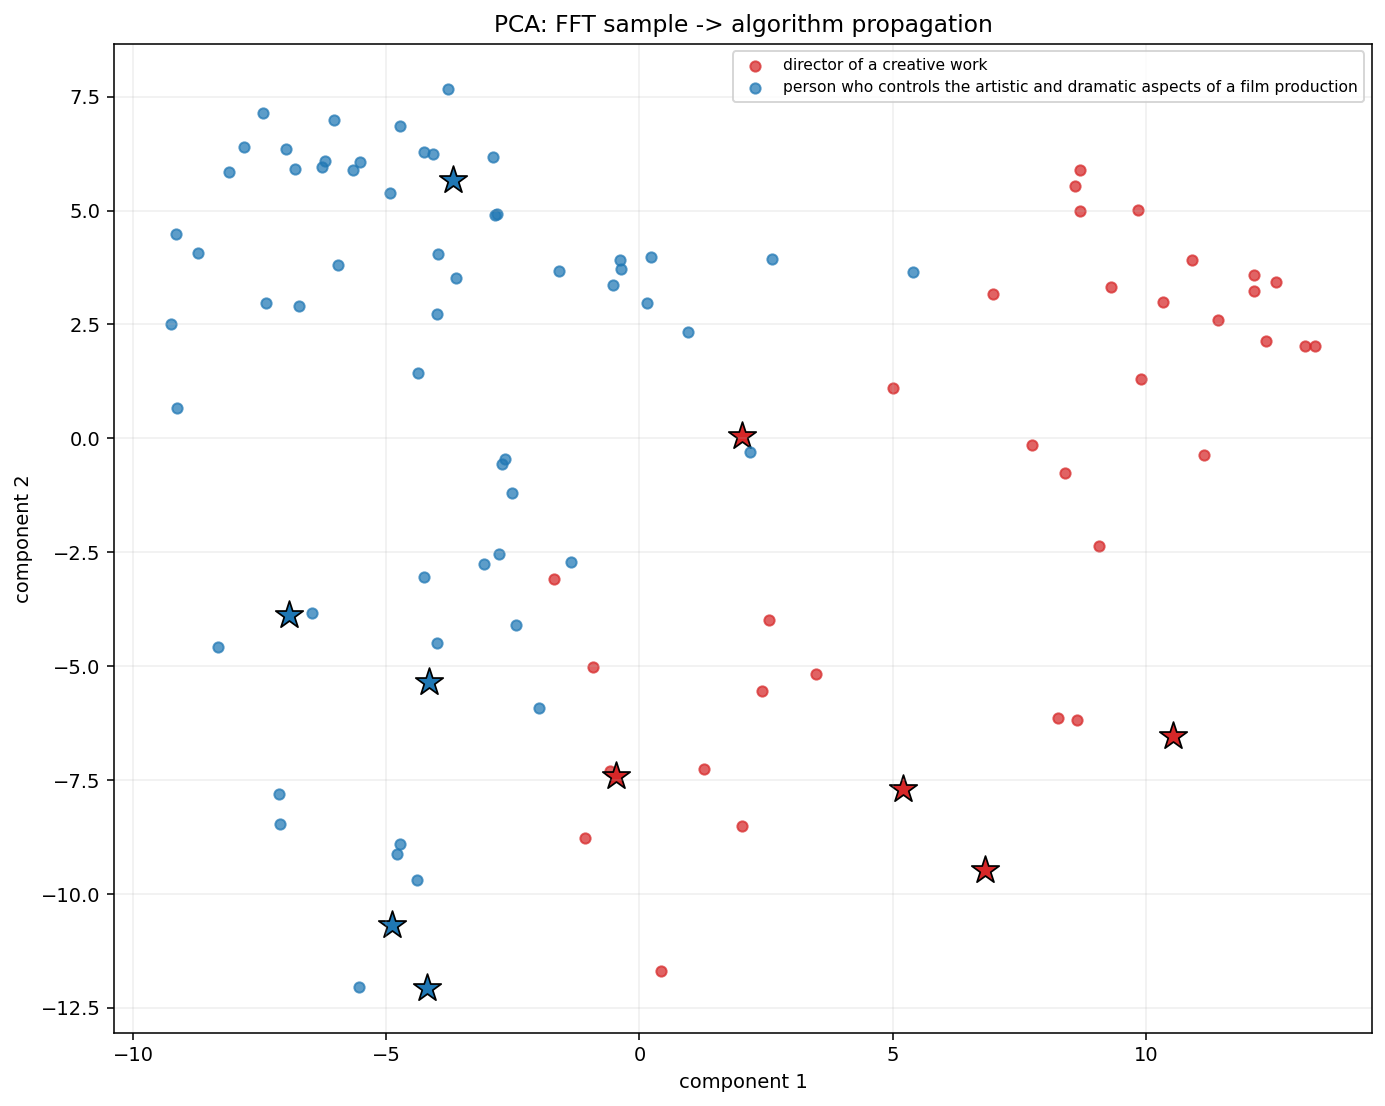

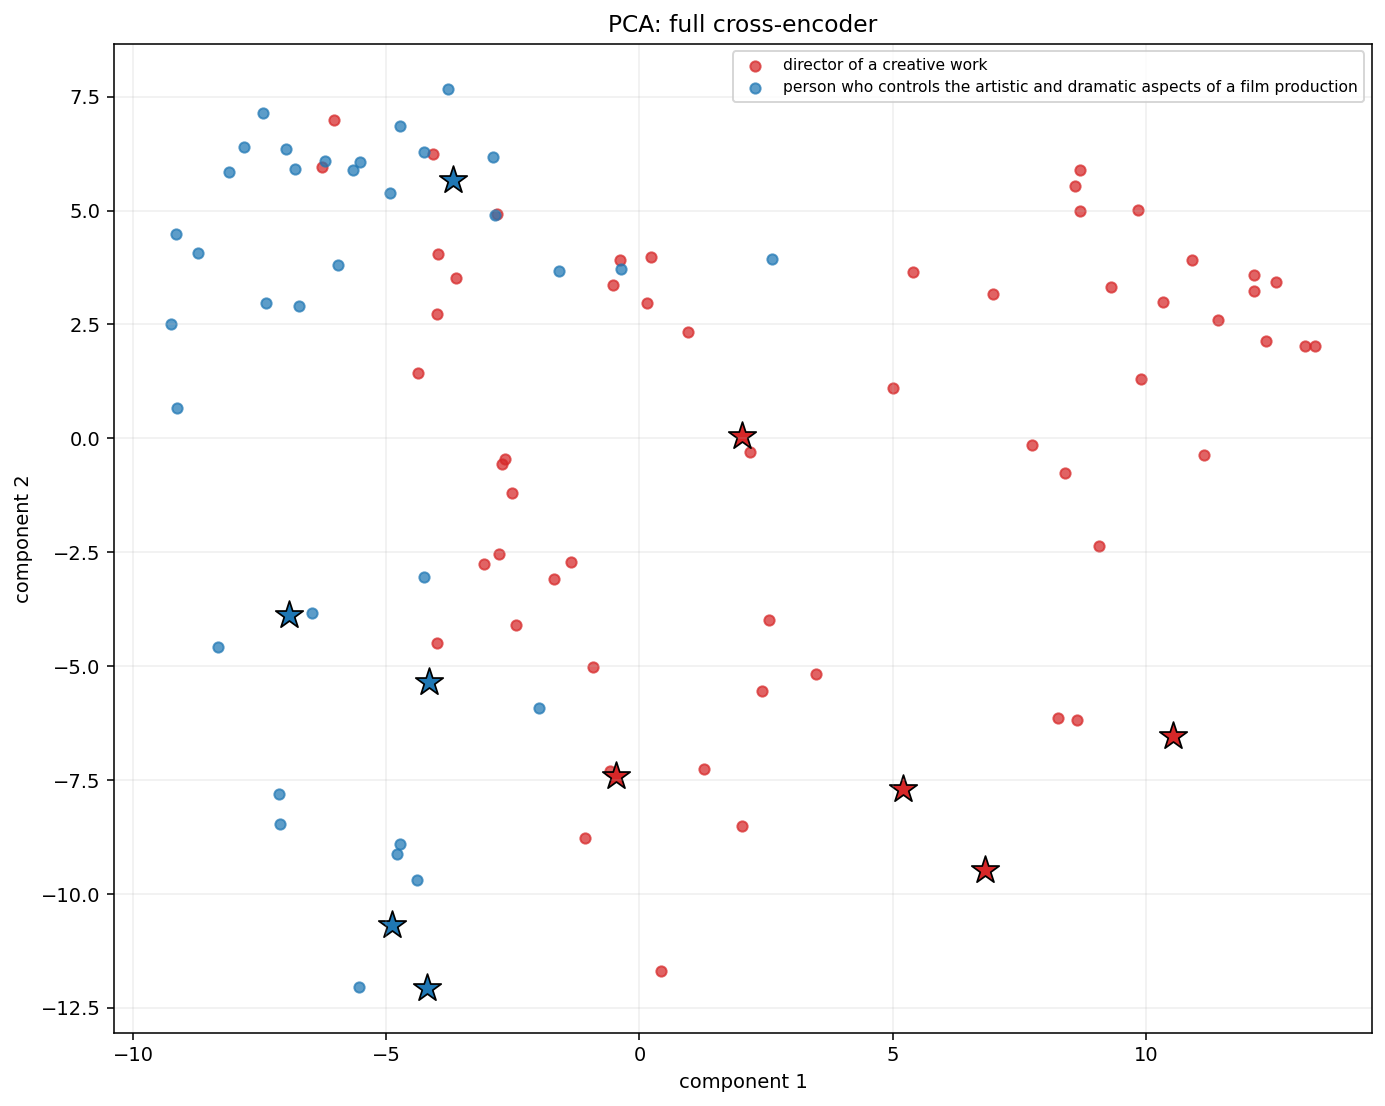

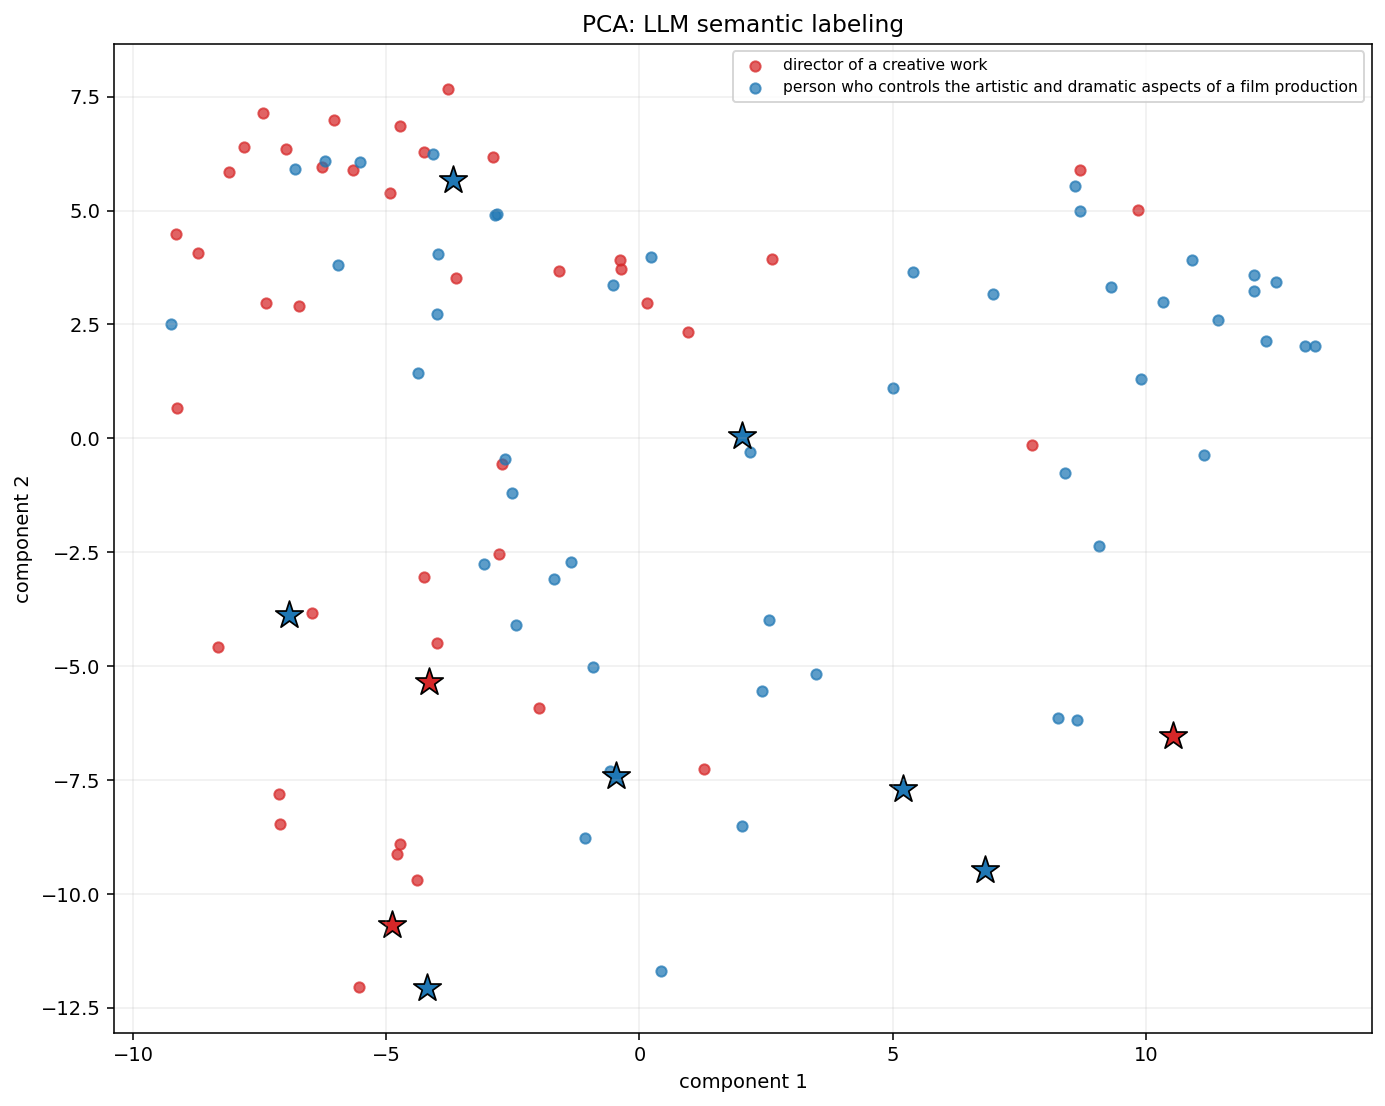

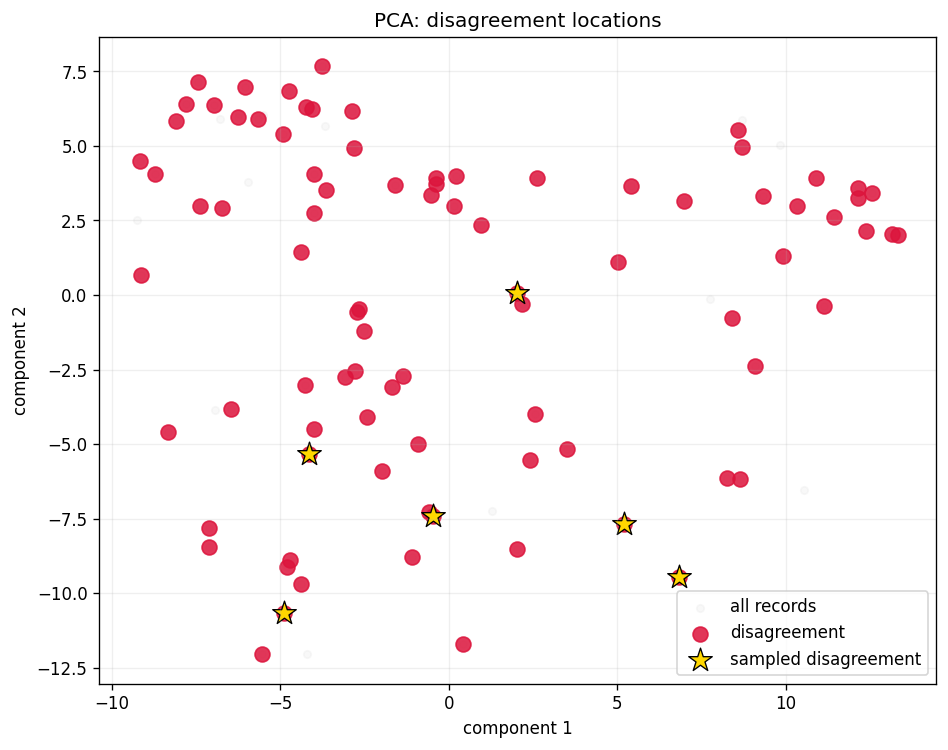

In [16]:
plot_assignment_comparison(
    records,
    comparison_df,
    sampled_indices=fft_result["sampled_indices"],
    method=REDUCTION_METHOD,
    random_state=RANDOM_STATE,
)

plot_disagreement_only(
    records,
    comparison_df,
    sampled_indices=fft_result["sampled_indices"],
    method=REDUCTION_METHOD,
    random_state=RANDOM_STATE,
)

In [17]:
provenance_counts = fft_assignment_df["provenance"].value_counts(dropna=False).rename_axis("provenance").reset_index(name="count")
display(provenance_counts)

display(
    fft_assignment_df[[
        "record_index",
        "title",
        "kind",
        "matched_text",
        "assigned_description",
        "provenance",
        "score",
    ]].head(50)
)

display(
    full_assignment_df[[
        "record_index",
        "title",
        "kind",
        "matched_text",
        "assigned_description",
        "score",
    ]].head(50)
)

if llm_assignment_df is not None:
    display(
        llm_assignment_df[[
            "record_index",
            "title",
            "kind",
            "matched_text",
            "assigned_description",
            "provenance",
            "llm_reason",
            "llm_cache_hit",
        ]].head(50)
    )
else:
    print("LLM validation is disabled.")


,provenance,count
0,d1_d2,57
1,model_judgment,33
2,class_seed,10


,record_index,title,kind,matched_text,assigned_description,provenance,score
0,0,Ed Wood,token,director,director of a creative work,d1_d2,NaN
1,1,David Weissman,token,director,director of a creative work,model_judgment,-1.386739
2,2,Ambroise Thomas,token,director,person who controls the artistic and dramatic aspects of a film production,d1_d2,NaN
3,3,Ferdinando Provesi,token,director,person who controls the artistic and dramatic aspects of a film production,d1_d2,NaN
4,4,United States Assistant Secretary of State,token,director,person who controls the artistic and dramatic aspects of a film production,d1_d2,NaN
5,5,Steven K. Galson,token,director,person who controls the artistic and dramatic aspects of a film production,class_seed,-2.550935
6,6,Robert R. Hood,token,director,person who controls the artistic and dramatic aspects of a film production,d1_d2,NaN
7,7,Heidi Ewing,token,director,director of a creative work,model_judgment,-1.657921
8,8,Heidi Ewing,token,director,person who controls the artistic and dramatic aspects of a film production,d1_d2,NaN
9,9,Antonino Lo Surdo,token,director,person who controls the artistic and dramatic aspects of a film production,d1_d2,NaN


,record_index,title,kind,matched_text,assigned_description,score
0,0,Ed Wood,token,director,director of a creative work,-1.388068
1,1,David Weissman,token,director,director of a creative work,-1.386739
2,2,Ambroise Thomas,token,director,director of a creative work,-1.408562
3,3,Ferdinando Provesi,token,director,director of a creative work,-2.111440
4,4,United States Assistant Secretary of State,token,director,person who controls the artistic and dramatic aspects of a film production,-3.374389
5,5,Steven K. Galson,token,director,person who controls the artistic and dramatic aspects of a film production,-2.550935
6,6,Robert R. Hood,token,director,person who controls the artistic and dramatic aspects of a film production,-3.100083
7,7,Heidi Ewing,token,director,director of a creative work,-1.657921
8,8,Heidi Ewing,token,director,director of a creative work,-1.522496
9,9,Antonino Lo Surdo,token,director,person who controls the artistic and dramatic aspects of a film production,-2.907663


,record_index,title,kind,matched_text,assigned_description,provenance,llm_reason,llm_cache_hit
0,0,Ed Wood,token,director,person who controls the artistic and dramatic aspects of a film production,llm_semantic_label,"The context mentions 'filmmaker' and 'film production', indicating a strong connection to the film industry, making the film director candidate the best fit.",True
1,1,David Weissman,token,director,person who controls the artistic and dramatic aspects of a film production,llm_semantic_label,"The context mentions 'film credits' and 'The Family Man' and 'Evolution', which are all related to the film industry, making 'film director' the most semantically fitting candidate.",True
2,2,Ambroise Thomas,token,director,director of a creative work,llm_semantic_label,"The context mentions the director of the Conservatoire de Paris, which is a creative work, making the candidate with label 'director' and description 'director of a creative work' the best fit.",True
3,3,Ferdinando Provesi,token,director,director of a creative work,llm_semantic_label,"The context suggests a director of a creative work, such as a music school or Philharmonic Society, which best fits the candidate meaning 'director of a creative work'.",True
4,4,United States Assistant Secretary of State,token,director,director of a creative work,llm_semantic_label,"The context mentions a bureau or another agency, suggesting a director in an organizational or administrative role, which is more closely related to the general term 'director' than a film or theatrical director.",True
5,5,Steven K. Galson,token,director,director of a creative work,llm_semantic_label,"The context mentions a director of a creative work, specifically the Center for Drug Evaluation and Research (CDER) at the Food and Drug Administration, which is a non-film or theatrical production.",True
6,6,Robert R. Hood,token,director,person who controls the artistic and dramatic aspects of a film production,llm_semantic_label,"The context suggests a role in a film or creative work, making the film director candidate the best fit.",True
7,7,Heidi Ewing,token,director,person who controls the artistic and dramatic aspects of a film production,llm_semantic_label,"The context mentions documentary films, which are a type of film, making the film director candidate the most semantically fitting choice.",True
8,8,Heidi Ewing,token,director,person who controls the artistic and dramatic aspects of a film production,llm_semantic_label,"The context mentions 'film' and 'production', which strongly suggests a film director, matching the definition of the first candidate.",True
9,9,Antonino Lo Surdo,token,director,director of a creative work,llm_semantic_label,"The context suggests a director of a creative work, which is a broader term that encompasses various types of directors, including film, theatre, and others.",True
